# EDA HOÀN CHỈNH: DATA PROFILING → DESCRIPTIVE STATISTICS → DEFINE THE QUESTION
## Dataset: `sales_data_sample.xlsx` (2,823 đơn hàng)

File này đi theo đúng cấu trúc 1 EDA (Exploratory Data Analysis) chuẩn:

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào (3 nhóm: Central Tendency, Dispersion, Location & Shape)
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh cụ thể, trả lời bằng code, rút insight
```

**Vì sao có Phần C?** Phần A và B chỉ mới "mô tả dữ liệu trông như thế nào" — Phần C mới là lúc biến những con số đó thành **câu trả lời cho câu hỏi kinh doanh thật**, đúng tinh thần EDA: mỗi phân tích luôn bắt đầu từ 1 câu hỏi, không phải chạy code trước rồi mới nghĩ hỏi gì.

## Setup

In [17]:
# %pip install matplotlib
# %pip install seaborn
# %pip install scipy
# %pip install stats
# %pip install openpyxl xlrd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_excel("data/sales_data_sample.xlsx")
df.head()

,ORDERNUMBER,QUANTITYORDERED,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,COUNTRY,DEALSIZE,Discount,Profit
0,10107,30,2,2871.00,2003-02-24,Shipped,USA,Small,0.00,41.9136
1,10121,34,5,2765.90,2003-05-07,Shipped,France,Small,0.00,219.5820
2,10134,41,2,3884.34,2003-07-01,Shipped,France,Medium,0.00,6.8714
3,10145,45,6,3746.70,2003-08-25,Shipped,USA,Medium,0.45,-383.0310
4,10159,49,14,5205.27,2003-10-10,Shipped,USA,Medium,0.20,2.5164


---
# PHẦN A — DATA PROFILING

## A.1. Data size, column names, data types

In [18]:
print("Số dòng:", df.shape[0], "| Số cột:", df.shape[1])
print()
df.info()

Số dòng: 2823 | Số cột: 10

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ORDERNUMBER      2823 non-null   int64         
 1   QUANTITYORDERED  2823 non-null   int64         
 2   ORDERLINENUMBER  2823 non-null   int64         
 3   SALES            2823 non-null   float64       
 4   ORDERDATE        2823 non-null   datetime64[ns]
 5   STATUS           2823 non-null   object        
 6   COUNTRY          2823 non-null   object        
 7   DEALSIZE         2823 non-null   object        
 8   Discount         2823 non-null   float64       
 9   Profit           2823 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 220.7+ KB


## A.2. Missing values & Duplicate data

In [32]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu.")
print()
print("Duplicate rows (toàn bộ):", df.duplicated().sum())
print("Duplicate theo khóa ORDERNUMBER+ORDERLINENUMBER:",
      df.duplicated(subset=['ORDERNUMBER','ORDERLINENUMBER']).sum())

Missing values:
Không có cột nào thiếu dữ liệu.

Duplicate rows (toàn bộ): 0
Duplicate theo khóa ORDERNUMBER+ORDERLINENUMBER: 0


## A.3. Invalid values (filter, groupby...)

In [20]:
print("QUANTITYORDERED <= 0:", (df['QUANTITYORDERED']<=0).sum())
print("SALES <= 0:", (df['SALES']<=0).sum())
print("Discount ngoài [0,1]:", ((df['Discount']<0)|(df['Discount']>1)).sum())
print("ORDERDATE ở tương lai:", (df['ORDERDATE']>pd.Timestamp.today()).sum())
print()
print("=> Dữ liệu khá sạch: không missing, không duplicate, không giá trị vô lý.")

QUANTITYORDERED <= 0: 0
SALES <= 0: 0
Discount ngoài [0,1]: 0
ORDERDATE ở tương lai: 0

=> Dữ liệu khá sạch: không missing, không duplicate, không giá trị vô lý.


## A.4. Create a new column
Tạo các cột hỗ trợ phân tích sẽ dùng ở Phần B, C: `ORDER_YEAR`, `ORDER_MONTH`, `PROFIT_MARGIN`.

In [21]:
df['ORDER_YEAR'] = df['ORDERDATE'].dt.year
df['ORDER_MONTH'] = df['ORDERDATE'].dt.month
df['PROFIT_MARGIN'] = df['Profit'] / df['SALES']
df[['ORDERDATE','ORDER_YEAR','ORDER_MONTH','Profit','SALES','PROFIT_MARGIN']].head()

,ORDERDATE,ORDER_YEAR,ORDER_MONTH,Profit,SALES,PROFIT_MARGIN
0,2003-02-24,2003,2,41.9136,2871.00,0.014599
1,2003-05-07,2003,5,219.5820,2765.90,0.079389
2,2003-07-01,2003,7,6.8714,3884.34,0.001769
3,2003-08-25,2003,8,-383.0310,3746.70,-0.102232
4,2003-10-10,2003,10,2.5164,5205.27,0.000483


---
# PHẦN B — DESCRIPTIVE STATISTICS

## Group 1 — Central Tendency (mean, median, mode)

In [22]:
for col in ['SALES','Profit']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")
print()
print("Mode DEALSIZE:", df['DEALSIZE'].mode()[0])

SALES: Mean=3553.89, Median=3184.80, Mode=3003.00
Profit: Mean=25.38, Median=8.88, Mode=0.00

Mode DEALSIZE: Medium


## Group 2 — Dispersion (range, var, std, IQR, CV)

In [23]:
for col in ['SALES','Profit']:
    s = df[col]
    range_ = s.max()-s.min()
    std_ = s.std()
    q1,q3 = s.quantile([0.25,0.75]); iqr = q3-q1
    cv = std_/s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- SALES ---
Range=13600.67, Std=1841.87, IQR=2304.57, CV=0.52
--- Profit ---
Range=7759.98, Std=192.45, IQR=28.69, CV=7.58


## Group 3 — Location and Shape (Percentile, Skewness, Kurtosis)

--- SALES ---
P25=2203.43, P50=3184.80, P75=4508.00
Skewness=1.16, Kurtosis=1.79
--- Profit ---
P25=1.80, P50=8.88, P75=30.49
Skewness=2.40, Kurtosis=169.18


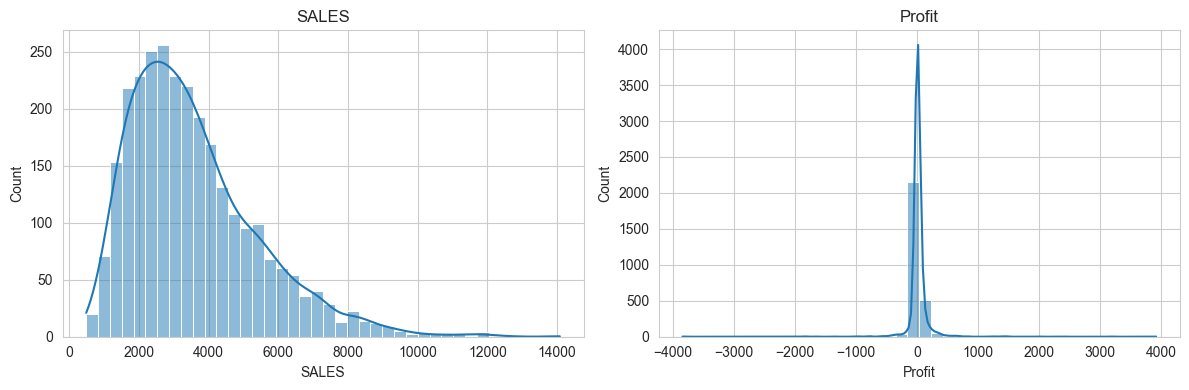

Nhận xét: Profit lệch phải và có kurtosis cao hơn hẳn SALES -> nhiều outlier lợi nhuận cực đoan hơn.


In [24]:
for col in ['SALES','Profit']:
    s = df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['SALES'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('SALES')
sns.histplot(df['Profit'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('Profit')
plt.tight_layout(); plt.show()

print("Nhận xét: Profit lệch phải và có kurtosis cao hơn hẳn SALES -> nhiều outlier lợi nhuận cực đoan hơn.")

---
# PHẦN C — DEFINE THE QUESTION 

Mỗi câu hỏi dưới đây theo đúng cấu trúc: **Câu hỏi → Code → Kết quả → Insight**.

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, và chiếm bao nhiêu % tổng doanh thu công ty?

COUNTRY
USA          3627983.0
Spain        1215687.0
France       1110917.0
Australia     630623.0
UK            478880.0
Name: SALES, dtype: float64

=> USA đóng góp 36.2% tổng doanh thu.


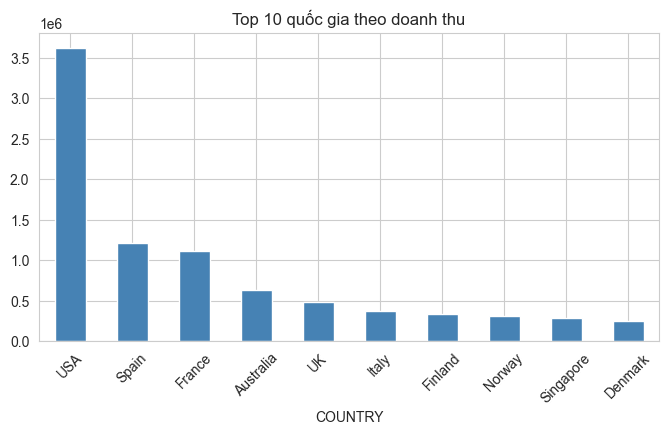

In [25]:
sales_by_country = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)
top_country = sales_by_country.index[0]
top_pct = sales_by_country.iloc[0] / sales_by_country.sum() * 100

print(sales_by_country.head(5).round(0))
print(f"\n=> {top_country} đóng góp {top_pct:.1f}% tổng doanh thu.")

fig,ax=plt.subplots(figsize=(8,4))
sales_by_country.head(10).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 quốc gia theo doanh thu'); plt.xticks(rotation=45); plt.show()

**Insight:** Doanh thu tập trung khá mạnh vào 1 vài thị trường trọng điểm (dẫn đầu là USA) — đây là rủi ro tập trung cần lưu ý: nếu thị trường này gặp vấn đề, ảnh hưởng đến tổng doanh thu công ty sẽ rất lớn.

## Câu hỏi 2: DEALSIZE nào có lợi nhuận ổn định nhất (rủi ro thấp nhất)?

In [26]:
stability = df.groupby('DEALSIZE')['Profit'].agg(['mean','std'])
stability['CV'] = stability['std'] / stability['mean']
print(stability.round(2).sort_values('CV'))

most_stable = stability['CV'].idxmin()
print(f"\n=> DEALSIZE ổn định nhất (CV thấp nhất): {most_stable}")

           mean     std     CV
DEALSIZE                      
Medium    28.54  182.80   6.40
Small     24.04  194.02   8.07
Large      8.48  253.45  29.88

=> DEALSIZE ổn định nhất (CV thấp nhất): Medium


**Insight:** Dùng CV thay vì Std thô để so sánh công bằng giữa các nhóm có quy mô lợi nhuận khác nhau — nhóm có CV thấp nhất là nhóm đáng tin cậy để dự báo lợi nhuận hơn.

## Câu hỏi 3: Giảm giá (Discount) có thực sự "ăn mòn" lợi nhuận không?

Pearson correlation: -0.252
Spearman correlation: -0.530


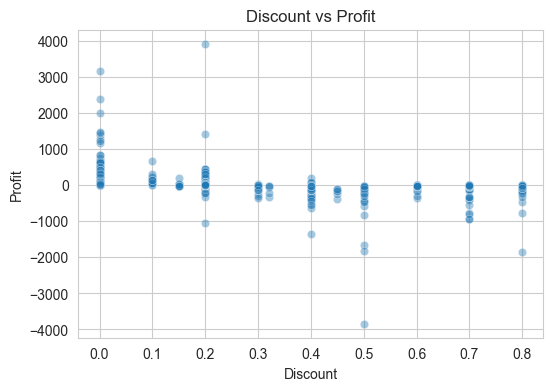

In [27]:
corr_pearson = df['Discount'].corr(df['Profit'])
corr_spearman = df['Discount'].corr(df['Profit'], method='spearman')
print(f"Pearson correlation: {corr_pearson:.3f}")
print(f"Spearman correlation: {corr_spearman:.3f}")

fig,ax=plt.subplots(figsize=(6,4))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, ax=ax)
ax.set_title('Discount vs Profit'); plt.show()

**Insight:** Hệ số tương quan cho biết mức độ liên hệ tuyến tính giữa 2 biến, nhưng **tương quan không chứng minh nhân quả** — cần thêm kiểm định thống kê suy diễn (giai đoạn sau) để kết luận chắc chắn giảm giá có "gây ra" giảm lợi nhuận hay không, hay do yếu tố khác (VD: loại đơn hàng) ảnh hưởng đồng thời.

## Câu hỏi 4: Doanh số có tính mùa vụ theo tháng không?

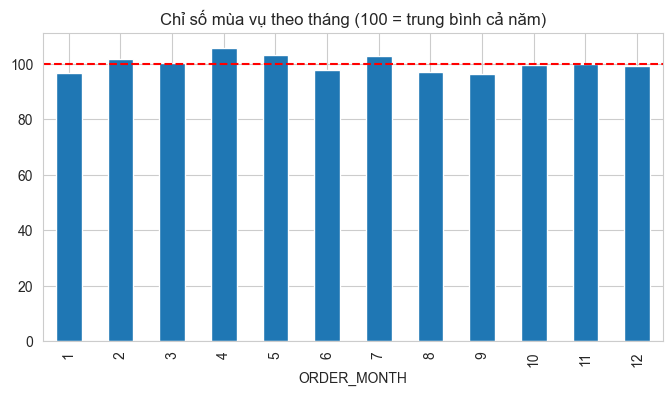

Tháng cao điểm: 4 (chỉ số 106)
Tháng thấp điểm: 9 (chỉ số 96)


In [28]:
seasonality = df.groupby('ORDER_MONTH')['SALES'].mean()
seasonality_index = (seasonality / seasonality.mean() * 100).round(1)

fig,ax=plt.subplots(figsize=(8,4))
seasonality_index.plot(kind='bar', ax=ax)
ax.axhline(100, color='red', linestyle='--')
ax.set_title('Chỉ số mùa vụ theo tháng (100 = trung bình cả năm)')
plt.show()

peak = seasonality_index.idxmax()
low = seasonality_index.idxmin()
print(f"Tháng cao điểm: {peak} (chỉ số {seasonality_index[peak]:.0f})")
print(f"Tháng thấp điểm: {low} (chỉ số {seasonality_index[low]:.0f})")

**Insight:** Nếu chỉ số mùa vụ dao động rõ rệt quanh mốc 100, doanh số có tính chu kỳ theo tháng — công ty nên chuẩn bị nguồn lực/tồn kho trước các tháng cao điểm, và cân nhắc chương trình kích cầu ở tháng thấp điểm.

## Câu hỏi 5: Tỷ lệ đơn hàng Cancelled/Disputed có khác nhau giữa các quốc gia không?

In [29]:
problem_rate = pd.crosstab(df['COUNTRY'], df['STATUS'], normalize='index') * 100
problem_rate['Problem_Rate'] = problem_rate.get('Cancelled',0) + problem_rate.get('Disputed',0)
print(problem_rate['Problem_Rate'].sort_values(ascending=False).head(5).round(2))

COUNTRY
Sweden       28.07
UK            9.72
Spain         6.43
Denmark       4.76
Australia     2.70
Name: Problem_Rate, dtype: float64


**Insight:** Nếu 1 vài quốc gia có tỷ lệ Cancelled/Disputed cao vượt trội so với phần còn lại, đây là tín hiệu cần điều tra vận hành riêng cho thị trường đó (logistics, chất lượng dịch vụ khách hàng địa phương).

## Câu hỏi 6: Xu hướng doanh số qua các năm ra sao?

In [30]:
yearly_sales = df.groupby('ORDER_YEAR')['SALES'].sum()
yoy_growth = yearly_sales.pct_change() * 100
print(pd.DataFrame({'SALES':yearly_sales.round(0), 'YoY_%':yoy_growth.round(2)}))
print()
print("Lưu ý: 2005 có thể chưa đủ 12 tháng dữ liệu, cần kiểm tra trước khi kết luận xu hướng giảm/tăng thật.")

                SALES  YoY_%
ORDER_YEAR                  
2003        3516980.0    NaN
2004        4724163.0  34.32
2005        1791487.0 -62.08

Lưu ý: 2005 có thể chưa đủ 12 tháng dữ liệu, cần kiểm tra trước khi kết luận xu hướng giảm/tăng thật.


**Insight:** Trước khi kết luận "tăng trưởng" hay "suy giảm" giữa các năm, luôn phải kiểm tra xem mỗi năm có đủ 12 tháng dữ liệu hay không — nếu năm cuối chỉ có vài tháng, so sánh trực tiếp tổng doanh số sẽ gây hiểu lầm.

---
# TỔNG KẾT

| Phần | Trả lời câu hỏi |
|---|---|
| A — Data Profiling | Dữ liệu có sạch, đáng tin cậy để phân tích không? |
| B — Descriptive Statistics | Từng biến (SALES, Profit) có đặc điểm gì (trung tâm, phân tán, hình dạng)? |
| C — Define the Question | Trả lời được bao nhiêu câu hỏi kinh doanh thật, có insight + khuyến nghị hành động? |

— khác với việc chỉ chạy `describe()` hay `value_counts()` đơn thuần, mỗi phân tích ở Phần C đều xuất phát từ 1 câu hỏi cụ thể và kết thúc bằng 1 insight có thể hành động được, đúng tinh thần "data storytelling" mà nhà tuyển dụng Data Analyst luôn tìm kiếm.